# 探索性資料分析 (Exploratory Data Analysis)

學習目標：
- 了解 EDA 的標準流程
- 學會檢查缺失值、分布、相關性
- 用真實資料集實作

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 載入內建資料集（企鵝資料）
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
df = pd.read_csv(url)

# 第一步：了解資料基本形狀
print('資料形狀：', df.shape)
print('\n欄位名稱：', df.columns.tolist())
print('\n資料型別：')
print(df.dtypes)

資料形狀： (344, 7)

欄位名稱： ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

資料型別：
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object


In [2]:
# 第二步：看前5筆資料長什麼樣子
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
# 第三步：檢查缺失值
print('各欄位缺失值數量：')
print(df.isnull().sum())
print(f'\n總缺失值比例：{df.isnull().mean().mean()*100:.1f}%')

各欄位缺失值數量：
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

總缺失值比例：0.8%


In [4]:
# 第四步：基本統計量
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


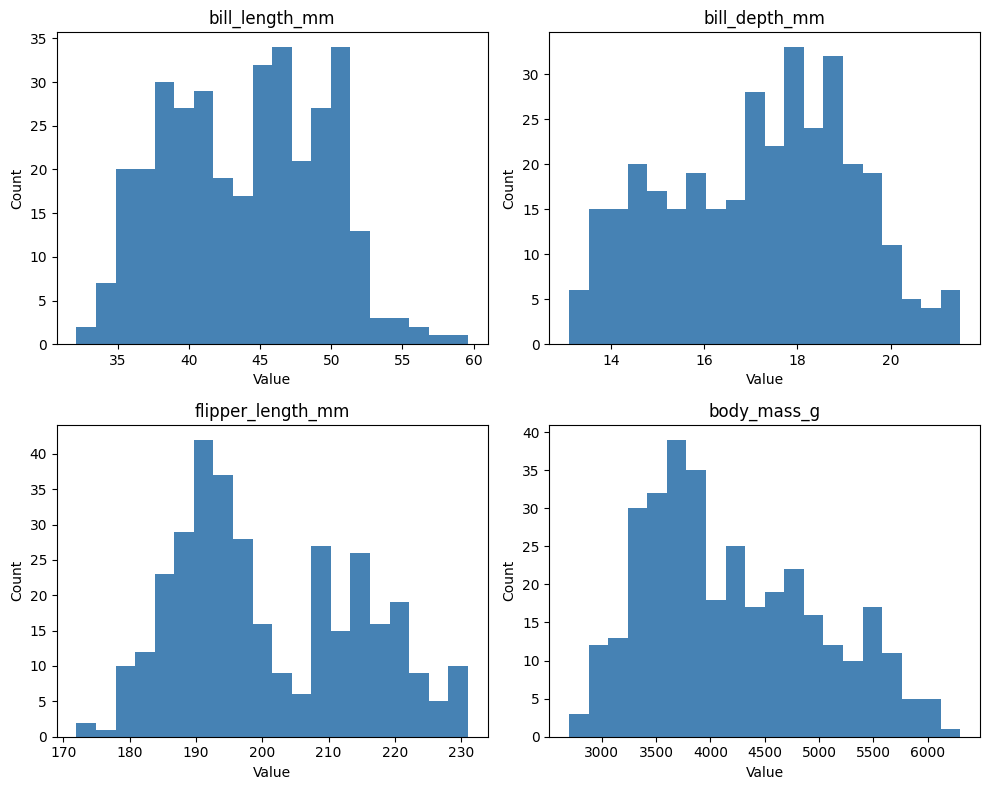

In [5]:
# 第五步：數值分布 - 畫出每個數值欄位的histogram
numeric_cols = ['bill_length_mm', 'bill_depth_mm',
                'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

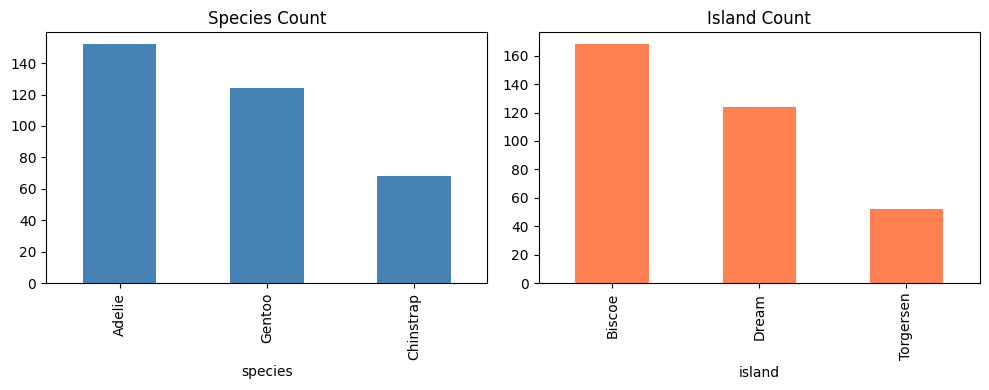

In [6]:
# 第六步：類別變數分布
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df['species'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Species Count')

df['island'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Island Count')

plt.tight_layout()
plt.show()

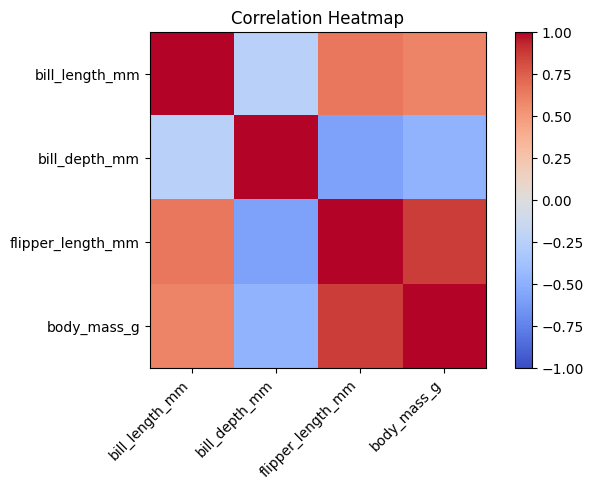


相關係數矩陣：
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.24               0.66   
bill_depth_mm               -0.24           1.00              -0.58   
flipper_length_mm            0.66          -0.58               1.00   
body_mass_g                  0.60          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.60  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


In [9]:
# 第七步：相關性分析
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\n相關係數矩陣：')
print(corr.round(2))


## 我的學習筆記

1. 這個主題在做什麼：
   EDA 是建立任何預測模型前的必要步驟，
   目的是了解資料的品質、分布和變數間的關係。

2. EDA 標準流程：
   資料形狀 → 缺失值 → 統計量 → 分布圖 → 相關性

3. 我覺得最難理解的地方：
   （填入你自己的想法）

4. 這個跟我研究的連結：
   分析運動員資料時，要先做 EDA 確認：
   - 哪些特徵跟成績相關性高（值得放入模型）
   - 資料有沒有缺失或異常值（影響模型品質）
  